   baseline value  accelerations  fetal_movement  uterine_contractions  \
0           120.0          0.000             0.0                 0.000   
1           132.0          0.006             0.0                 0.006   
2           133.0          0.003             0.0                 0.008   
3           134.0          0.003             0.0                 0.008   
4           132.0          0.007             0.0                 0.008   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0                0.000                   0.0                       0.0   
1                0.003                   0.0                       0.0   
2                0.003                   0.0                       0.0   
3                0.003                   0.0                       0.0   
4                0.000                   0.0                       0.0   

   abnormal_short_term_variability  mean_value_of_short_term_variability  \
0                             73.0

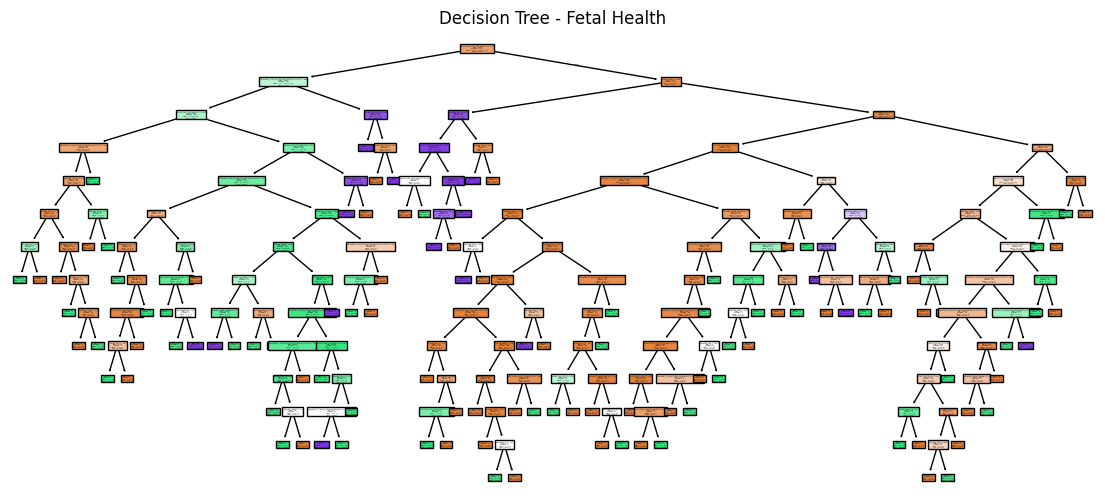


--- Random Forest Classifier ---
Accuracy: 0.9460093896713615
Confusion Matrix:
 [[327   5   1]
 [ 13  49   2]
 [  1   1  27]]
Classification Report:
               precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       333
         2.0       0.89      0.77      0.82        64
         3.0       0.90      0.93      0.92        29

    accuracy                           0.95       426
   macro avg       0.92      0.89      0.90       426
weighted avg       0.94      0.95      0.94       426



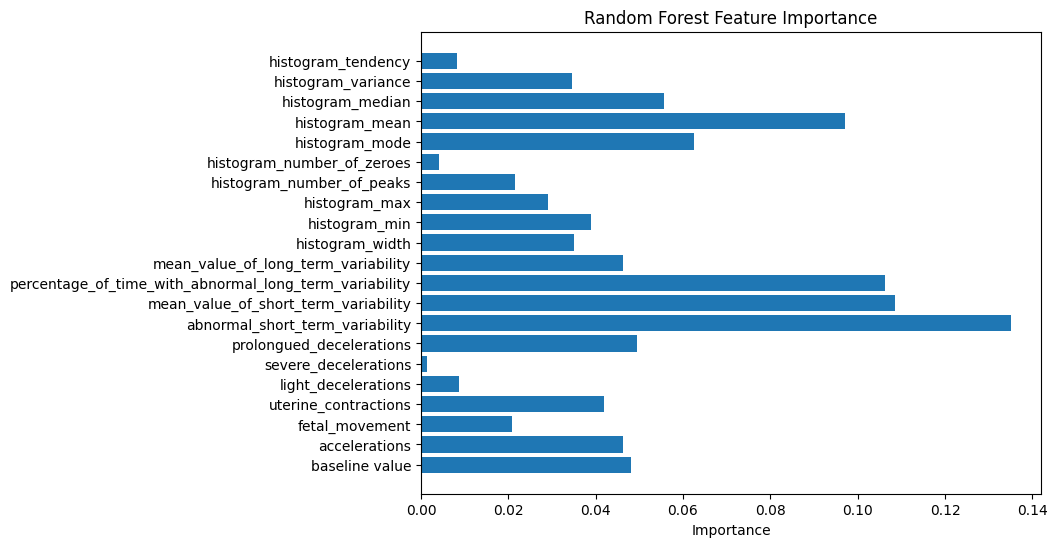

In [ ]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ===============================
# LOAD DATASET
# ===============================
df = pd.read_csv("fetal_health.csv")

print(df.head())
print(df.shape)
print(df['fetal_health'].value_counts())


# ===============================
# FEATURES & TARGET
# ===============================
X = df.drop("fetal_health", axis=1)
y = df["fetal_health"]   # 1 = Normal, 2 = Suspect, 3 = Pathological


# ===============================
# TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ===============================
# DECISION TREE CLASSIFIER
# ===============================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("\n--- Decision Tree Classifier ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))


# ===============================
# DECISION TREE VISUALIZATION
# ===============================
plt.figure(figsize=(14, 6))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Normal", "Suspect", "Pathological"],
    filled=True
)
plt.title("Decision Tree - Fetal Health")
plt.show()


# ===============================
# RANDOM FOREST CLASSIFIER
# ===============================
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n--- Random Forest Classifier ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


# ===============================
# FEATURE IMPORTANCE (RANDOM FOREST)
# ===============================
importances = rf.feature_importances_

plt.figure(figsize=(8, 6))
plt.barh(X.columns, importances)
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()
